# Plot comparison between $M_0$ and local normal stress

Plot the comparison to the local normal stress for revision.

2025.12.07 Kurama Okubo


In [1]:
import os
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
import matplotlib as mpl
from matplotlib import ticker
import matplotlib.ticker as mticker

%matplotlib inline
import numpy as np
import pandas as pd
import datetime
from datetime import timedelta
from tqdm import tqdm
import warnings
import time
import pickle 
import seaborn as sns
import copy

import scipy.io as sio
from scipy.signal import decimate

%load_ext autoreload
%autoreload 2

plt.rcParams["font.family"] = 'Arial'
# plt.rcParams["font.sans-serif"] = "DejaVu Sans, Arial, Helvetica, Lucida Grande, Verdana, Geneva, Lucid, Avant Garde, sans-serif"
plt.rcParams["font.size"] = 12
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["xtick.major.size"] = 4.75
plt.rcParams["xtick.major.width"] = 0.75
plt.rcParams["xtick.minor.size"] = 3
plt.rcParams["xtick.minor.width"] = 0.4
plt.rcParams["xtick.minor.visible"] = True

plt.rcParams["ytick.direction"] = "in"
plt.rcParams["ytick.major.size"] = 4.75
plt.rcParams["ytick.major.width"] = 0.75
plt.rcParams["ytick.minor.size"] = 3
plt.rcParams["ytick.minor.width"] = 0.4
plt.rcParams["ytick.minor.visible"] = True

plt.rcParams["savefig.transparent"] = False #True


In [2]:
# datadir = "../data/M0vsStressDrop/"
# if not os.path.exists(datadir):
#     os.makedirs(datadir)

figdir = "../figure/M0vsLocalNormalStress/"
if not os.path.exists(figdir):
    os.makedirs(figdir)


In [3]:
expr_id = 87
GP_id = "P3"

# Load normal stress data

In [4]:
fi_localsn = f"../data/gp_normalstress_fb03-{expr_id:03d}_{GP_id}.csv"

In [5]:
df_localsn= pd.read_csv(fi_localsn, index_col=0)
df_localsn.head()

,stickslip_id,gougeevent_id,event_time,event_loc_m,mean_SGT,mean_flatjack
expr_id,,,,,,
87,3,4,0.054381,1.75,1.076905,1.943764
87,5,9,0.041049,1.75,1.038201,1.944030
87,8,18,0.045511,1.75,1.045816,1.944115
87,9,19,0.045370,1.75,1.049004,1.944642
87,9,20,0.045720,1.75,1.048228,1.944157


# Load gouge event catalog

In [6]:
# read gouge event catalog
gougepatch_id = "G3"
Qinv_quart = 50

Nvalidsensors_thresh = 4

finame = f"../../../../GougeEventCatalog/data/gougeeventcatalog__fb03-{expr_id:03d}__{gougepatch_id}__Q{Qinv_quart}.csv"
df_gc = pd.read_csv(finame, index_col=0)
df_gc_selected = df_gc[df_gc["Nvalidsensors"] >= Nvalidsensors_thresh].copy()
df_gc_selected.head()

,location,event_onset_time,stickslip_id,event_label,Q_correction_quart,Nvalidsensors,M0,M0_std,Mw,Tw,Tw_std
event_id,,,,,,,,,,,
4,1.75,42.474772,3,A,50,4,0.594031,0.179160,-6.217460,0.000003,1.516442e-07
9,1.75,47.662693,5,F,50,4,0.047135,0.007497,-6.951102,0.000002,3.630314e-07
18,1.75,56.727044,8,F,50,4,0.757592,0.193624,-6.147043,0.000003,3.109912e-07
19,1.75,59.103175,9,F,50,4,0.056071,0.017249,-6.900839,0.000002,2.699614e-07
20,1.75,59.103526,9,F,50,4,0.867075,0.209970,-6.107962,0.000003,1.379112e-07


# Link the gouge event and local normal stress

In [7]:
df_localsn.loc[df_localsn["gougeevent_id"]==4, "mean_SGT"].values[0]

1.07690466503903

In [8]:
df_gc_selected = df_gc_selected.merge(
    df_localsn[["gougeevent_id", "mean_SGT"]], # using the average of SGT near the P3
    how="left",
    left_index=True,
    right_on="gougeevent_id"
)

df_gc_selected = df_gc_selected.set_index("gougeevent_id")
df_gc_selected = df_gc_selected.rename(columns={"mean_SGT": "LocalNormalStress"})

In [9]:
df_gc_selected

,location,event_onset_time,stickslip_id,event_label,Q_correction_quart,Nvalidsensors,M0,M0_std,Mw,Tw,Tw_std,LocalNormalStress
gougeevent_id,,,,,,,,,,,,
4,1.75,42.474772,3,A,50,4,0.594031,0.179160,-6.217460,0.000003,1.516442e-07,1.076905
9,1.75,47.662693,5,F,50,4,0.047135,0.007497,-6.951102,0.000002,3.630314e-07,1.038201
18,1.75,56.727044,8,F,50,4,0.757592,0.193624,-6.147043,0.000003,3.109912e-07,1.045816
19,1.75,59.103175,9,F,50,4,0.056071,0.017249,-6.900839,0.000002,2.699614e-07,1.049004
20,1.75,59.103526,9,F,50,4,0.867075,0.209970,-6.107962,0.000003,1.379112e-07,1.048228
21,1.75,63.752300,10,F,50,4,0.021673,0.003116,-7.176053,0.000002,2.064907e-07,1.084772
24,1.75,66.186944,11,F,50,4,0.065804,0.021153,-6.854498,0.000002,2.825796e-07,1.051226
27,1.75,76.018478,14,F,50,4,0.763685,0.210829,-6.144724,0.000003,2.019305e-07,1.097007
31,1.75,79.320093,15,F,50,4,0.974691,0.262768,-6.074089,0.000003,2.155345e-07,1.076152


In [10]:
def M02Mw(M0):
    return (np.log10(M0) - 9.1) * 2.0 / 3.0 # synchronized with OpenSWPC : moment_magnitude ( m0 )

def Mw2M0(Mw):
    return 10**( 1.5 * Mw + 9.05) # synchronized with OpenSWPC : seismic_moment ( mw )
   

In [11]:
scatter_mc = sns.color_palette("Set1")
scatter_mc

[(0.8941176470588236, 0.10196078431372549, 0.10980392156862745),
 (0.21568627450980393, 0.49411764705882355, 0.7215686274509804),
 (0.30196078431372547, 0.6862745098039216, 0.2901960784313726),
 (0.596078431372549, 0.3058823529411765, 0.6392156862745098),
 (1.0, 0.4980392156862745, 0.0),
 (1.0, 1.0, 0.2),
 (0.6509803921568628, 0.33725490196078434, 0.1568627450980392),
 (0.9686274509803922, 0.5058823529411764, 0.7490196078431373),
 (0.6, 0.6, 0.6)]

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


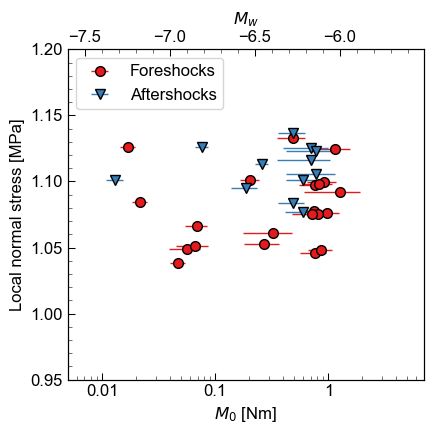

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(4.5, 4.5))
mainmarkersize=7

df_gc_fore = df_gc_selected[df_gc_selected["event_label"]=="F"]
df_gc_after = df_gc_selected[df_gc_selected["event_label"]=="A"]
# df_gc_fore.plot.scatter(x="Shearstress_before", y="Mw", s=60, ax=ax, color="r", marker="o", edgecolor="k", zorder=3, label="Foreshock")
ax.errorbar(df_gc_fore["M0"].values, df_gc_fore["LocalNormalStress"].values, xerr=df_gc_fore["M0_std"].values,
           capsize=0, fmt="o", markersize=mainmarkersize, color=scatter_mc[0], lw=1, markeredgecolor = "k", label="Foreshocks", zorder=3)

ax.errorbar(df_gc_after["M0"].values, df_gc_after["LocalNormalStress"].values, xerr=df_gc_after["M0_std"].values,
           capsize=0, fmt="v", markersize=mainmarkersize, color=scatter_mc[1], lw=1, markeredgecolor = "k", label="Aftershocks", zorder=3)


ax.set_xlabel("$M_0$ [Nm]")
ax.set_ylabel("Local normal stress [MPa]")


ax.set_xscale('log')
# ax.set_yscale('log')

xlimit_scaling = [5e-3, 7]
ax.set_xlim(xlimit_scaling)

ax.set_ylim([0.95, 1.2])
# ax.set_yticks(np.arange(0.64, 0.67, 0.005))
# ax.set_yticklabels(np.arange(0.64, 0.67, 0.005))

plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter())
plt.gca().yaxis.set_minor_formatter(ticker.NullFormatter())

ax.legend(loc=2)

ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2g'))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

#-----------------------#
#--- plot double axis---#
#-----------------------#

# https://pythonmatplotlibtips.blogspot.com/2018/01/add-second-x-axis-below-first-x-axis-python-matplotlib-pyplot.html
ax2 = ax.twiny()
ax2.set_xlabel("$M_w$")
ax2.set_xlim([M02Mw(xlimit_scaling[0]), M02Mw(xlimit_scaling[1])]) # synchronize with the first axis

# major tick
newlabel = np.array([-7.5, -7, -6.5, -6.0,])
ax2.minorticks_on()
ax2.set_xticks(newlabel)

# ax.grid(True, c=np.array([230, 230, 230])/255, lw=0.25, zorder=-1)
# ax.set_axisbelow('True')

plt.tight_layout()

plt.savefig(figdir+f"/M0vsLocalNormalStress_fb03-{expr_id:03d}_{gougepatch_id}_Q{Qinv_quart}.png", format="png", dpi=70)
plt.savefig(figdir+f"/M0vsLocalNormalStress_fb03-{expr_id:03d}_{gougepatch_id}_Q{Qinv_quart}.eps", format="eps")
# plt.savefig(figdir+f"/M0vsLocalNormalStress_fb03-{expr_id:03d}_{gougepatch_id}_Q{Qinv_quart}.pdf")
